# 🎯 미션: cGAN을 활용한 FashionMNIST 조건부 이미지 생성 👕

## 1. 미션 소개

이번 미션에서는 **cGAN (Conditional GAN)** 모델을 활용하여 **FashionMNIST 데이터셋**의 각 패션 아이템(예: 티셔츠, 바지, 스니커즈 등)을 **조건부로 생성**하는 작업을 수행합니다.

-   **🎯 핵심 목표:** 각 클래스(레이블)에 해당하는 이미지를 생성하는 cGAN 모델을 직접 설계하고 학습시킵니다.

---

## 2. 📊 데이터 소개

-   **데이터셋:** FashionMNIST
-   **⬇️ 다운로드:** `torchvision.datasets.FashionMNIST`를 통해 바로 다운로드 가능합니다.
-   **🗂️ 데이터 구성:**
    -   **훈련 데이터:** 60,000장의 이미지
    -   **테스트 데이터:** 10,000장의 이미지
-   **🔳 이미지 사양:** 28×28 크기의 흑백 이미지 (총 10개 클래스)
-   **📋 클래스 목록 (10개):**
    1.  👕 T-shirt/top
    2.  👖 Trouser
    3.  🧥 Pullover
    4.  👗 Dress
    5.  🧥 Coat (Note: Pullover와 아이콘 중복)
    6.  👡 Sandal
    7.  👔 Shirt
    8.  👟 Sneaker
    9.  👜 Bag
    10. 👢 Ankle boot

---

## 3. 📤 제출 안내

**Colab Notebook (`.ipynb`)** 파일을 제출해 주세요.

-   **📛 파일 이름:** `09_{팀명}_{성함}.ipynb`
-   **✅ 필수 포함 내용:**
    1.  **🔄 분석 과정과 결과**
        -   데이터 로드, 전처리, cGAN 모델 설계, 학습, 생성 이미지 예측 및 평가 과정을 순차적으로 진행해야 합니다.
    2.  **🔀 조건부 생성 구현**
        -   조건부 레이블을 활용해 각 패션 아이템 클래스별로 이미지를 생성하는 모델을 구현해야 합니다.
    3.  **✍️ 마크다운을 활용한 상세 설명**
        -   각 코드 셀이 수행하는 작업 (의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
        -   노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해야 합니다.

---

## 4. 🏆 모델 성능 평가 및 제출

-   **🧐 평가 방식:**
    -   **👀 정성적 평가 (필수):** 생성된 이미지의 품질을 시각적으로 평가합니다.
    -   **📊 정량적 평가 (Optional):** FID, IS 등의 지표를 활용하여 평가할 수 있습니다.
-   **📮 최종 제출:**
    -   테스트 데이터셋에 대한 모델의 조건부 생성 성능을 확인할 수 있는 결과와 함께 Notebook 파일을 제출합니다.

---

## 5. 📚 참고 사항

-   **🔗 Baseline 코드:**
    -   미션 시작에 도움이 필요하다면 [Baseline 코드 링크 (FashionMNIST)]를 참고할 수 있습니다.
    -   이 코드는 기본적인 형태로 제공되며, 자유롭게 변형하여 사용할 수 있습니다.
-   **⚠️ 주의 사항:**
    -   Baseline 코드는 참고 자료일 뿐, 이를 그대로 사용하는 것보다 **이를 기반으로 자신의 아이디어를 추가하고 발전시키는 것이 중요합니다.**
    -   ✨ 가능하면 스스로 모델을 구축해보고 다양한 방법을 시도하여 성능을 향상시켜 보세요.

---

## 6. 🚀 모델 성능 개선 팁 (Optional)

-   **🖼️ 데이터 증강 (Data Augmentation):**
    -   이미지 회전, 크롭, 밝기/대비 조절 등으로 모델의 일반화 성능을 높여보세요.
-   **🎛️ 하이퍼파라미터 튜닝:**
    -   학습률(Learning rate), 배치 크기(Batch size), 에폭(Epoch) 수 등을 조정하여 최적의 성능을 도출해 보세요.
-   **🏛️ 모델 구조 개선:**
    -   조건부 생성 네트워크(Generator/Discriminator)에 추가적인 레이어 등을 도입하여 성능 개선을 시도해 보세요.

## 1. Phase 1: 준비 단계 (Setup)

### - 1.1 미션 정의 및 환경 설정:



In [10]:
#@title Improt lib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import random

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
#@title (Jupyter) 로컬 저장 경로 설정
import os

# 모델 파일 등을 저장할 로컬 경로
g_path = './data' 
# g_path = './my_cgan_project' # 혹은 원하는 다른 경로로 수정 가능

# 해당 폴더가 존재하지 않으면 자동으로 생성
os.makedirs(g_path, exist_ok=True)

print(f"모델이 저장될 경로: {g_path}")

모델이 저장될 경로: ./data


In [12]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed) # GPU 사용 시 GPU 관련 연산의 시드도 고정
random.seed(seed)
np.random.seed(seed)

In [14]:
#하이퍼파라미터 및 환경 설정

image_size = 28      # Fashion MNIST 이미지 크기
num_classes = 10     # 10개 클래스
latent_dim = 100     # 잠재 공간 차원 (생성자가 사용할 노이즈 벡터 크기)
batch_size = 64      # 학습 배치 크기
num_epochs = 200     # 전체 학습 에폭 수
lr = 0.0002          # 학습률 (Learning Rate): GAN 학습 안정화를 위해 일반적으로 낮은 값 사용
beta1 = 0.5          # Adam optimizer beta1: DCGAN 논문에서 제안된 값 (강사님 참고)
beta2 = 0.999        # Adam optimizer beta2: Adam optimizer의 기본값 (강사님 참고)

## 2. Phase 2: 데이터 처리 (Data)


### - 2.1 데이터 로드 및 탐색 (EDA):

In [15]:
#@title Transform 설정

# 학습용 데이터 증강 transform
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),         # 20% 확률로 좌우 반전
    transforms.RandomRotation(10),                  # ±10도 범위 내에서 랜덤 회전
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # 최대 10% 이동
    transforms.RandomResizedCrop(28, scale=(0.8, 1.0), ratio=(0.9, 1.1)), # 랜덤 크롭 후 28x28로 리사이즈
    transforms.ToTensor(),                          # 텐서로 변환 (0~1 스케일)
    transforms.Normalize((0.5,), (0.5,))            # -1~1 스케일로 정규화
])

# 평가용 transform (증강 없이 정규화만)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

### - 2.2 데이터 전처리 및 파이프라인 구축:

In [17]:
#@title Dataset + Data Loader

train_dataset = torchvision.datasets.FashionMNIST(
    root='g_path',         # 데이터가 저장될 로컬 경로
    train=True,            # 훈련용 데이터셋
    download=True,         # 로컬 경로에 데이터가 없으면 다운로드
    transform=train_transforms # 훈련용 변형 규칙 적용
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='g_path',
    train=False,           # 테스트용 데이터셋
    download=True,
    transform=test_transforms  # 평가용 변형 규칙 적용
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size, # 하이퍼파라미터로 정의한 배치 크기 (64) -> 나중에 변경가능.
    shuffle=True           # 훈련 데이터는 섞어서 사용 (멘토님 설명 : 과적합 방지용)
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False          # 평가 데이터는 순서대로 사용
)

100%|██████████████████████████████████████| 26.4M/26.4M [00:07<00:00, 3.67MB/s]
100%|██████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 99.5kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 1.52MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 3.72MB/s]


In [19]:
#@title 클래스 이름 설정 (FashionMNIST 클래스)
idx_to_class = {i: class_name for i, class_name in enumerate(train_dataset.classes)}
print("FashionMNIST classes:", idx_to_class)

# 이게 7번 클래스야"라고 하는 것보다 "이건 'Sneaker'야"라고 말하는 것이 훨씬 직관적.
# (train_dataset.classes)에 저장된 클래스 이름 리스트
# 숫자(인덱스)와 이름(클래스명)을 짝지어주는 사전(idx_to_class)

FashionMNIST classes: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


## 3. 모델 설정

### - 3.1 cGAN 핵심 원리 이해: Generator 와 Discriminator 를 모두 생성해야함.

In [23]:
#@title Generator Model (강사님 파일 참조)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        # [조건] 레이블 임베딩: num_classes (10) 개의 클래스를 num_classes (10) 차원 벡터로 변환
        self.label_emb = nn.Embedding(num_classes, num_classes)

        # 초기 크기 계산: 28x28 이미지를 4로 나눈 7x7에서 시작
        self.init_size = image_size // 4  # 28/4 = 7

        # 첫 번째 선형 레이어: (잠재 공간 + 레이블 임베딩) 차원을 입력받음
        # (latent_dim + num_classes) -> 128 * 7 * 7
        self.l1 = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 128 * self.init_size * self.init_size),
            nn.ReLU(inplace=True)
        )

        # Conv 블록: 7x7에서 28x28로 업샘플링
        self.conv_blocks = nn.Sequential(
            # (B, 128, 7, 7)
            nn.BatchNorm2d(128, momentum=0.8),
            nn.Upsample(scale_factor=2),  # 7x7 -> 14x14
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            
            # (B, 128, 14, 14)
            nn.BatchNorm2d(128, momentum=0.8),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            
            # (B, 64, 14, 14)
            nn.BatchNorm2d(64, momentum=0.8),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),  # 14x14 -> 28x28
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),

            # (B, 32, 28, 28)
            nn.BatchNorm2d(32, momentum=0.8),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1), # 1채널 (흑백)
            
            # (B, 1, 28, 28)
            nn.Tanh()  # 출력을 -1 ~ 1 사이로
        )

    def forward(self, noise, labels):
        # 1. 레이블을 임베딩 벡터로 변환 (B, 10)
        label_input = self.label_emb(labels)
        
        # 2. 노이즈(B, 100)와 레이블 벡터(B, 10)를 결합 (B, 110)
        gen_input = torch.cat((noise, label_input), -1)
        
        # 3. 선형 레이어 통과 (B, 128 * 7 * 7)
        out = self.l1(gen_input)
        
        # 4. 이미지 씨앗 형태로 Reshape (B, 128, 7, 7)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        
        # 5. Conv 블록을 통과하여 최종 이미지 생성 (B, 1, 28, 28)
        img = self.conv_blocks(out)
        return img

In [24]:
#@title Discriminator Model

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # [조건] 레이블 임베딩: num_classes (10)를 1차원 값으로 임베딩
        # (Generator와 달리, 여기서는 채널에 합치기 위한 간단한 표현으로 1차원만 사용)
        self.label_emb = nn.Embedding(num_classes, 1)

        self.model = nn.Sequential(
            # 입력: (B, 1+1, 28, 28) -> 이미지(1채널)와 레이블(1채널)을 합쳐 2채널 입력
            nn.Conv2d(1 + 1, 64, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 64, 14, 14)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),   # 14x14 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 128, 7, 7)
            nn.Flatten(), # (B, 128 * 7 * 7)
            nn.Linear(128 * (image_size // 4) * (image_size // 4), 1), # 128*7*7 -> 1
            nn.Sigmoid() # 출력을 0~1 (진짜/가짜 확률) 사이로
        )

    def forward(self, img, labels):
        batch_size = img.size(0)
        
        # 1. 레이블 임베딩 (B, 1)
        label = self.label_emb(labels)
        # 2. 레이블을 이미지 크기(1x28x28)로 확장
        label = label.view(batch_size, 1, 1, 1)
        label = label.expand(batch_size, 1, image_size, image_size)
        
        # 3. 이미지(B, 1, 28, 28)와 레이블(B, 1, 28, 28)을 채널 차원에서 연결 (B, 2, 28, 28)
        d_in = torch.cat((img, label), 1)
        
        # 4. 모델 통과하여 최종 판별 결과(확률) 도출
        validity = self.model(d_in)
        return validity

### - 3.2 학습 필요한 도구들 설정 (손실, 옵티마이저)

In [25]:
#@title 모델 초기화 및 optimizer 설정

# 1. 생성자와 판별자 모델 인스턴스화 및 device로 이동
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 2. 손실 함수 (Binary Cross Entropy Loss)
adversarial_loss = nn.BCELoss()

# 3. Generator를 위한 Adam optimizer 설정
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))

# 4. Discriminator를 위한 Adam optimizer 설정
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

## Phase 4: 모델 학습 (Training)

### - 4.1 학습 루프 구현:

In [26]:
#@title 한 에폭 학습 함수

import torch
# (matplotlib.pyplot은 이 함수 자체에서는 사용되지 않지만,
# 원본 코드 구조를 따라 일단 포함시킬 수 있습니다.
# 다음 시각화 함수(Step 13)에서 주로 사용됩니다.)
import matplotlib.pyplot as plt 

def train_one_epoch(generator, discriminator,
                      optimizer_G, optimizer_D,
                      adversarial_loss,
                      train_loader,
                      device, latent_dim, num_classes):
    """
    한 에폭 동안 Generator·Discriminator 학습하고
    평균 손실 및 판별자 출력 통계 반환
    """
    g_loss_sum = d_loss_sum = d_real_sum = d_fake_sum = 0.0
    num_batches = 0

    # 모델을 학습 모드로 설정
    generator.train()
    discriminator.train()

    # 데이터 로더에서 이미지와 레이블 가져오기
    for imgs, labels in train_loader:
        batch_size = imgs.size(0)
        imgs, labels = imgs.to(device), labels.to(device)

        # 실제 이미지(valid)와 가짜 이미지(fake)에 대한 정답 레이블 생성
        valid = torch.ones(batch_size, 1, device=device, dtype=torch.float32) # float32로 명시 (BCELoss 호환)
        fake  = torch.zeros(batch_size, 1, device=device, dtype=torch.float32)

        # --------------------------------
        # 1. 생성자(G)가 가짜 이미지를 미리 생성
        # --------------------------------
        # 노이즈 벡터 생성
        z = torch.randn(batch_size, latent_dim, device=device) 
        # 생성할 이미지의 랜덤 레이블 생성 (조건)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device) 
        # 노이즈와 레이블을 이용해 가짜 이미지 생성
        gen_imgs = generator(z, gen_labels)

        # --------------------------------
        # 2. 판별자(D) 학습
        # --------------------------------
        optimizer_D.zero_grad() # D 옵티마이저 그래디언트 초기화
        
        # [Real Loss] 실제 이미지를 진짜(valid)로 판별하도록 학습
        real_validity = discriminator(imgs, labels) 
        d_real_loss = adversarial_loss(real_validity, valid)

        # [Fake Loss] 가짜 이미지를 가짜(fake)로 판별하도록 학습
        # (중요) generator의 학습을 방지하기 위해 .detach() 사용
        fake_validity = discriminator(gen_imgs.detach(), gen_labels) 
        d_fake_loss = adversarial_loss(fake_validity, fake)

        d_loss = 0.5 * (d_real_loss + d_fake_loss) # D 전체 손실
        d_loss.backward() # 역전파
        optimizer_D.step() # D 가중치 업데이트

        # --------------------------------
        # 3. 생성자(G) 학습
        # --------------------------------
        optimizer_G.zero_grad() # G 옵티마이저 그래디언트 초기화
        
        # D가 가짜 이미지를 진짜(valid)로 판별하도록 학습
        validity = discriminator(gen_imgs, gen_labels) 
        g_loss = adversarial_loss(validity, valid) 
        
        g_loss.backward() # 역전파 (이때는 G의 가중치가 업데이트됨)
        optimizer_G.step() # G 가중치 업데이트

        # --------------------------------
        # 4. 통계 누적
        # --------------------------------
        g_loss_sum   += g_loss.item()
        d_loss_sum   += d_loss.item()
        d_real_sum   += real_validity.mean().item() # 실제 이미지에 대한 D 평균 출력 (1에 가까워야 함)
        d_fake_sum   += fake_validity.mean().item() # 가짜 이미지에 대한 D 평균 출력 (0에 가까워야 함)
        num_batches  += 1

    # 평균값 계산하여 반환
    return {
        "g_loss":   g_loss_sum / num_batches,
        "d_loss":   d_loss_sum / num_batches,
        "d_real":   d_real_sum / num_batches,
        "d_fake":   d_fake_sum / num_batches,
    }

### - 4.2 이미지 생성 및 시각화 함수

In [33]:
#@title (수정) 이미지 생성·시각화 함수

@torch.no_grad() # 그래디언트 계산 비활성화
def visualize_generated_images(generator,
                               epoch,
                               latent_dim,
                               num_classes,
                               device,
                               idx_to_class,
                               n_row=3, # (이 변수명은 '행의 개수'를 의미하게 됨)
                               show_every=10): # 몇 에폭마다 실행할지
    """
    지정된 에폭 주기에 고정된 노이즈와 레이블로
    이미지를 생성하여 시각화합니다.
    """
    
    # 지정된 주기가 아니면 실행하지 않음 (강사님 조언 반영)
    if epoch % show_every != 0 and epoch != 1 and epoch != num_epochs:
        return

    # 모델을 평가 모드로 설정
    generator.eval()

    # (n_row=3 이면) 클래스당 3개씩 이미지 생성
    n_images_per_class = n_row
    
    # 총 이미지 개수: 10 * 3 = 30
    total_images = num_classes * n_images_per_class
    # 고정 노이즈 (30, 100)
    z = torch.randn(total_images, latent_dim, device=device)

    # 고정 레이블 (0, 0, 0, 1, 1, 1, ..., 9, 9, 9)
    labels = torch.arange(num_classes, device=device).repeat_interleave(n_images_per_class)

    # 이미지 생성
    gen_imgs = generator(z, labels)
    
    # 이미지 스케일 복원: [-1, 1] -> [0, 1] (시각화를 위해)
    gen_imgs = (gen_imgs + 1) / 2.0 
    
    # ----- 여기가 수정된 부분입니다 -----
    # 복잡한 계산 대신, 10개 클래스를 한 줄에 나열하도록
    # nrow(number of columns)를 num_classes (10)로 고정합니다. (정수형)
    grid_img = vutils.make_grid(gen_imgs.cpu(), nrow=num_classes, padding=2, normalize=True)
    # -----------------------------------
    
    # n_row=3 (3줄)에 맞춰 figsize도 (15, 6) 정도로 조정
    plt.figure(figsize=(15, 6)) 
    plt.axis("off")
    plt.title(f"Epoch: {epoch} - Generated Images")
    plt.imshow(np.transpose(grid_img, (1, 2, 0))) # (C, H, W) -> (H, W, C)
    
    # 클래스 제목 (10개 클래스를 위에 표시)
    class_titles = " | ".join([f"{idx_to_class[i]} ({i})" for i in range(num_classes)])
    
    # (수정) 제목 위치가 그리드 위로 가도록 조정 (y=1.05)
    plt.text(0.5, 1.05, class_titles, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)
    
    plt.show()

In [34]:
# 전체 학습 루프 함수

import os # os.path.join을 사용하기 위해 import (Step 12에서 이미 했다면 생략 가능)

def train_cgan(num_epochs,
               generator, discriminator,
               optimizer_G, optimizer_D,
               adversarial_loss,
               train_loader,
               device, latent_dim,
               num_classes, idx_to_class,
               g_path): # 모델 저장을 위해 g_path를 인자로 받습니다.
    
    # 지정된 에폭 수만큼 학습 반복
    for epoch in range(1, num_epochs + 1):
        # 1. 한 에폭 학습 실행 및 통계 반환
        stats = train_one_epoch(generator, discriminator,
                                optimizer_G, optimizer_D,
                                adversarial_loss,
                                train_loader,
                                device, latent_dim, num_classes)

        # 2. 현재 에폭의 학습 결과 출력
        print(f"Epoch [{epoch}/{num_epochs}] "
              f"G_loss: {stats['g_loss']:.4f}  "
              f"D_loss: {stats['d_loss']:.4f}  "
              f"D(x): {stats['d_real']:.4f}  "    # D가 진짜를 진짜로 본 평균 확률
              f"D(G(x)): {stats['d_fake']:.4f}") # D가 가짜를 가짜로 본 평균 확률

        # 3. 지정된 주기에 생성된 이미지 시각화
        # (show_every=10은 visualize_generated_images 함수의 기본값으로 사용됨)
        visualize_generated_images(generator,
                                   epoch, latent_dim,
                                   num_classes, device,
                                   idx_to_class,
                                   n_row=3, show_every=10) # 10 에폭마다 + 1 에폭, 마지막 에폭

        # 4. 매 에폭마다 모델 상태 저장
        # g_path는 우리가 Phase 1에서 설정한 './data' 경로입니다.
        torch.save(generator.state_dict(), os.path.join(g_path, f"generator_epoch_{epoch}.pth"))
        torch.save(discriminator.state_dict(), os.path.join(g_path, f"discriminator_epoch_{epoch}.pth"))
        
        # 저장 완료 메시지 (너무 자주 출력되면 지저분하므로 10 에폭마다 또는 마지막에만 출력)
        if epoch % 10 == 0 or epoch == num_epochs:
             print(f"Saved models for epoch {epoch} to {g_path}")

한번 시작해보입시더
Epoch [1/200] G_loss: 0.7513  D_loss: 0.6846  D(x): 0.5103  D(G(x)): 0.4892


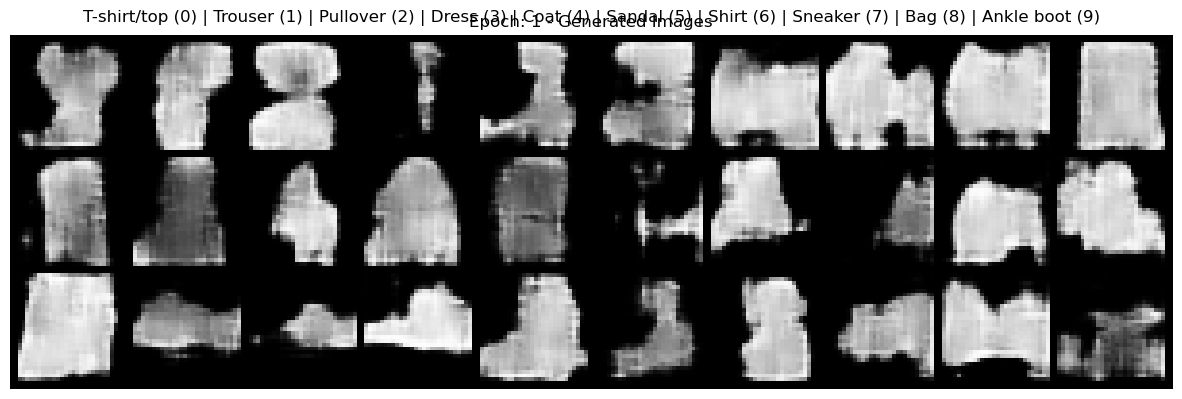

Epoch [2/200] G_loss: 0.7309  D_loss: 0.6927  D(x): 0.5048  D(G(x)): 0.4953
Epoch [3/200] G_loss: 0.7174  D_loss: 0.6985  D(x): 0.5001  D(G(x)): 0.4993
Epoch [4/200] G_loss: 0.7124  D_loss: 0.6985  D(x): 0.4999  D(G(x)): 0.4998
Epoch [5/200] G_loss: 0.7075  D_loss: 0.6983  D(x): 0.5001  D(G(x)): 0.5008
Epoch [6/200] G_loss: 0.7072  D_loss: 0.6982  D(x): 0.5001  D(G(x)): 0.5004
Epoch [7/200] G_loss: 0.7047  D_loss: 0.6976  D(x): 0.4995  D(G(x)): 0.5005
Epoch [8/200] G_loss: 0.7055  D_loss: 0.6973  D(x): 0.4996  D(G(x)): 0.5000
Epoch [9/200] G_loss: 0.7028  D_loss: 0.6968  D(x): 0.4997  D(G(x)): 0.5005
Epoch [10/200] G_loss: 0.7015  D_loss: 0.6964  D(x): 0.5001  D(G(x)): 0.5005


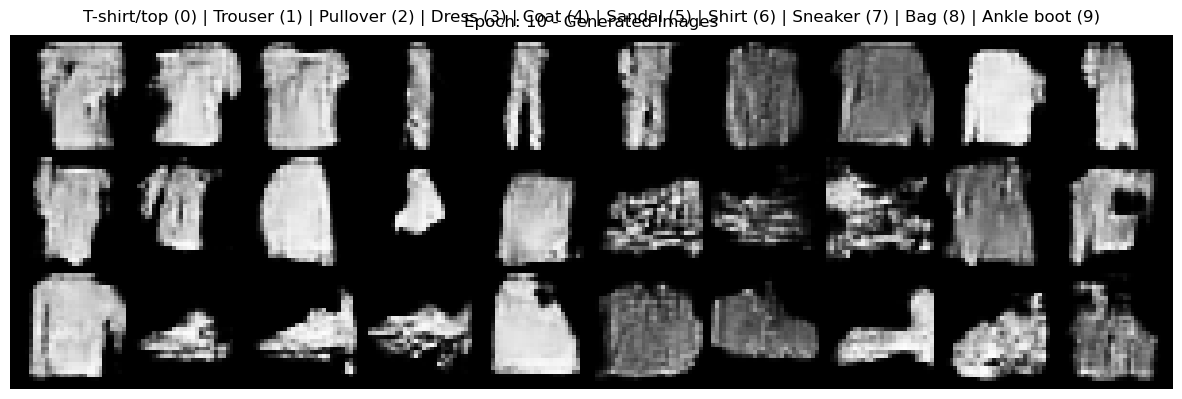

Saved models for epoch 10 to ./data
Epoch [11/200] G_loss: 0.7015  D_loss: 0.6964  D(x): 0.4994  D(G(x)): 0.5000
Epoch [12/200] G_loss: 0.7025  D_loss: 0.6958  D(x): 0.4998  D(G(x)): 0.4996
Epoch [13/200] G_loss: 0.6996  D_loss: 0.6964  D(x): 0.4997  D(G(x)): 0.5007
Epoch [14/200] G_loss: 0.6994  D_loss: 0.6960  D(x): 0.4998  D(G(x)): 0.5005
Epoch [15/200] G_loss: 0.6991  D_loss: 0.6960  D(x): 0.4996  D(G(x)): 0.5004
Epoch [16/200] G_loss: 0.6994  D_loss: 0.6960  D(x): 0.4993  D(G(x)): 0.5002
Epoch [17/200] G_loss: 0.6989  D_loss: 0.6958  D(x): 0.4994  D(G(x)): 0.5005
Epoch [18/200] G_loss: 0.7002  D_loss: 0.6952  D(x): 0.5002  D(G(x)): 0.4999
Epoch [19/200] G_loss: 0.6993  D_loss: 0.6954  D(x): 0.4996  D(G(x)): 0.5000
Epoch [20/200] G_loss: 0.6976  D_loss: 0.6955  D(x): 0.4999  D(G(x)): 0.5007


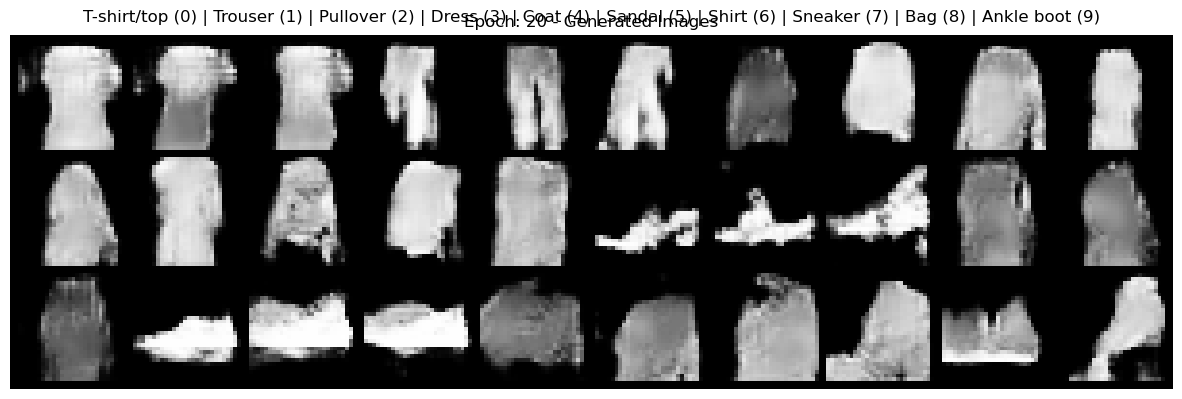

Saved models for epoch 20 to ./data
Epoch [21/200] G_loss: 0.6985  D_loss: 0.6954  D(x): 0.4995  D(G(x)): 0.5003
Epoch [22/200] G_loss: 0.6981  D_loss: 0.6949  D(x): 0.5000  D(G(x)): 0.5002
Epoch [23/200] G_loss: 0.6990  D_loss: 0.6953  D(x): 0.4995  D(G(x)): 0.4999
Epoch [24/200] G_loss: 0.6979  D_loss: 0.6949  D(x): 0.5000  D(G(x)): 0.5001
Epoch [25/200] G_loss: 0.6967  D_loss: 0.6953  D(x): 0.4997  D(G(x)): 0.5005
Epoch [26/200] G_loss: 0.6969  D_loss: 0.6951  D(x): 0.4994  D(G(x)): 0.5002
Epoch [27/200] G_loss: 0.6965  D_loss: 0.6948  D(x): 0.4997  D(G(x)): 0.5002
Epoch [28/200] G_loss: 0.6968  D_loss: 0.6944  D(x): 0.5009  D(G(x)): 0.5004
Epoch [29/200] G_loss: 0.6977  D_loss: 0.6947  D(x): 0.4994  D(G(x)): 0.4996
Epoch [30/200] G_loss: 0.6955  D_loss: 0.6949  D(x): 0.4999  D(G(x)): 0.5006


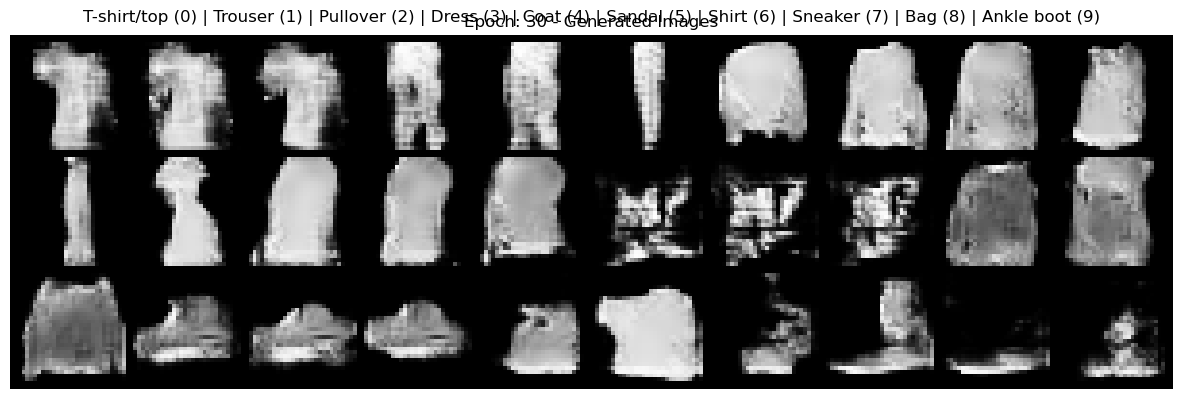

Saved models for epoch 30 to ./data
Epoch [31/200] G_loss: 0.6985  D_loss: 0.6942  D(x): 0.5002  D(G(x)): 0.4993
Epoch [32/200] G_loss: 0.6977  D_loss: 0.6942  D(x): 0.5000  D(G(x)): 0.4997


KeyboardInterrupt: 

In [35]:
#@title 학습 실행

print("한번 시작해보입시더")

train_cgan(
    num_epochs=num_epochs,                  # 200 에폭
    generator=generator,                    # 생성자 모델
    discriminator=discriminator,            # 판별자 모델
    optimizer_G=optimizer_G,                # G 옵티마이저
    optimizer_D=optimizer_D,                # D 옵티마이저
    adversarial_loss=adversarial_loss,      # BCELoss
    train_loader=train_loader,              # 훈련 데이터 로더
    device=device,                          # 'cuda' 또는 'cpu'
    latent_dim=latent_dim,                  # 100
    num_classes=num_classes,                # 10
    idx_to_class=idx_to_class,              # 클래스 이름 딕셔너리
    g_path=g_path                           # 모델 저장 경로 ('./data')
)

print("Training finished!")

## 5. Phase 5: 평가 및 개선 (Evaluation & Upgrade)

### - 5.1 결과 시각화 (1차):

In [39]:
#학습된 모델 로드
num_epochs = 30

import os # (이미 import 되었다면 생략 가능)

# 1. Generator 모델을 다시 인스턴스화합니다.
generator_loaded = Generator().to(device)

# 2. 저장된 state_dict의 경로를 지정합니다.
# (num_epochs는 Step 5에서 200으로 정의했습니다)
model_path = os.path.join(g_path, f"generator_epoch_{num_epochs}.pth") 

# 3. state_dict를 로드합니다.
try:
    generator_loaded.load_state_dict(torch.load(model_path, map_location=device))
    # 4. 평가 모드로 설정 (Dropout, BatchNorm 등이 평가 모드로 동작)
    generator_loaded.eval() 
    print(f"Generator model loaded from {model_path}")
except FileNotFoundError:
    print(f"Error: Model file not found at {model_path}")
    print("Please check if training completed and the file was saved correctly.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

Generator model loaded from ./data/generator_epoch_30.pth


In [40]:
#Inception Model 준비
import torch.nn.functional as F
from torchvision.models import inception_v3
from scipy.linalg import sqrtm # FID 계산 시 행렬 제곱근을 위해 필요
import numpy as np # (이미 import 되었다면 생략 가능)

# Inception-v3 모델 준비 (FID용: fc를 Identity로 변경)
# weights="IMAGENET1K_V1" -> 사전 훈련된 가중치 사용
inception_model_fid = inception_v3(weights="IMAGENET1K_V1", transform_input=False).to(device)
inception_model_fid.fc = torch.nn.Identity()  # fc 제거해서 2048차원 feature 반환
inception_model_fid.eval() # 평가 모드

# Inception-v3 모델 준비 (IS용: 기본 모델)
inception_model_is = inception_v3(weights="IMAGENET1K_V1", transform_input=False).to(device)
inception_model_is.eval() # 평가 모드

print("Inception models (for FID and IS) loaded")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/moon/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|████████████████████████████████████████| 104M/104M [00:02<00:00, 48.3MB/s]


Inception models (for FID and IS) loaded


In [42]:
#Inception Feature 추출 함수 + Fréchet Inception Distance (FID) 계산 함수

# 입력 이미지는 [-1,1] 범위라고 가정하고, 
# 함수 내부에서 [0,1]로 변환 후 Inception-v3용 정규화를 수행합니다.
# (원본 코드는 [0,1] 입력을 가정했으나, Step 20에서 [0,1]로 변환하므로 일치합니다.)

def get_inception_features(images, model, batch_size=32, device=device):
    """
    Inception-v3 모델을 사용하여 이미지에서 특징 추출 (FID용)
    images: [0, 1] 범위의 텐서
    """
    model.eval() # 모델을 평가 모드로 설정
    n_images = images.shape[0]
    features = []
    
    # Inception-v3의 입력 정규화 값 (ImageNet 기준)
    norm_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    norm_std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    
    with torch.no_grad(): # 그래디언트 계산 비활성화
        for i in range(0, n_images, batch_size):
            batch = images[i:i+batch_size]
            
            # 1. 흑백(1채널)이면 3채널로 복제
            if batch.shape[1] == 1:
                batch = batch.repeat(1,3,1,1)
                
            # 2. 299x299로 업샘플링 (Inception-v3 입력 크기)
            batch = F.interpolate(batch, size=(299,299), mode='bilinear', align_corners=False)
            
            # 3. Inception-v3용 정규화 (ImageNet 기준)
            # (입력 이미지가 [0,1] 범위라고 가정)
            batch = (batch - norm_mean) / norm_std
            
            # 4. 특징 추출 (fc가 Identity로 변경된 모델 사용)
            pred = model(batch) 
            features.append(pred.cpu().numpy()) # 추출된 특징을 CPU로 이동
            
    features = np.concatenate(features, axis=0) # 모든 배치의 특징을 하나로 연결
    return features


def calculate_fid(real_images, generated_images, model, batch_size=32, device=device):
    """
    실제 이미지와 생성된 이미지 간의 FID (Fréchet Inception Distance) 계산
    real_images, generated_images: torch.Tensor, [0,1] 범위
    """
    # 1. 실제 이미지 특징 추출
    feat_real = get_inception_features(real_images, model, batch_size, device)
    # 2. 생성된 이미지 특징 추출
    feat_gen  = get_inception_features(generated_images, model, batch_size, device)

    # 3. 각 그룹의 평균(mu)과 공분산(sigma) 계산
    mu_real = np.mean(feat_real, axis=0)
    mu_gen  = np.mean(feat_gen, axis=0)
    sigma_real = np.cov(feat_real, rowvar=False)
    sigma_gen  = np.cov(feat_gen, rowvar=False)

    # 4. Frechet Distance 공식
    diff = mu_real - mu_gen
    
    # 공분산 행렬의 제곱근 계산
    # (scipy.linalg.sqrtm 사용)
    covmean, _ = sqrtm(sigma_real.dot(sigma_gen), disp=False)
    
    # 복소수 부분이 생기면 실수부만 취함
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # 5. FID 계산
    fid = diff.dot(diff) + np.trace(sigma_real + sigma_gen - 2 * covmean)
    return fid

In [43]:
# Inception Prediction 함수 + Inception Score (IS) 계산 함수

def get_inception_predictions(images, model, batch_size=32, device=device):
    """
    Inception-v3 모델을 사용하여 이미지의 클래스 예측 확률 추출 (IS용)
    images: [0, 1] 범위의 텐서
    """
    model.eval() # 모델을 평가 모드로 설정
    n_images = images.shape[0]
    preds = []
    
    # Inception-v3의 입력 정규화 값 (ImageNet 기준)
    norm_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    norm_std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    
    with torch.no_grad(): # 그래디언트 계산 비활성화
        for i in range(0, n_images, batch_size):
            batch = images[i:i+batch_size]
            
            # 1. 흑백(1채널)이면 3채널로 복제
            if batch.shape[1] == 1:
                batch = batch.repeat(1,3,1,1)
                
            # 2. 299x299로 업샘플링
            batch = F.interpolate(batch, size=(299,299), mode='bilinear', align_corners=False)
            
            # 3. Inception-v3용 정규화
            batch = (batch - norm_mean) / norm_std

            # 4. Inception-v3의 로짓(logits) 출력
            logits = model(batch)
            
            # 5. 소프트맥스 함수를 적용하여 확률로 변환 (p(y|x))
            p = F.softmax(logits, dim=1) 
            preds.append(p.cpu().numpy()) # 예측 확률을 CPU로 이동
            
    preds = np.concatenate(preds, axis=0) # 모든 배치의 예측 확률을 하나로 연결
    return preds

def calculate_inception_score(
        generated_images,     # 생성된 이미지 텐서, 값 범위 [0,1]
        model,                # 사전학습 Inception-v3 (softmax 출력 유지)
        batch_size: int = 32, # 추론 시 배치 크기
        splits: int = 10,     # 이미지 분할(split) 개수
        device=device):       # 연산 장치(GPU/CPU)

    # 1) 모든 생성 이미지(N개)의 클래스 확률 p(y|x) (N, 1000) 배열 추출
    preds = get_inception_predictions(
        generated_images, model,
        batch_size=batch_size, device=device)

    N = preds.shape[0]      # 전체 이미지 수
    split_scores = []       # 분할별 IS를 저장할 리스트

    # 2) 데이터를 `splits` 개 구간으로 나눠 분할별 IS 계산 (편향·분산 안정화)
    for i in range(splits):
        # i번째 분할(slice) 선택 -> shape: (N/splits, 1000)
        part = preds[i * (N // splits):(i + 1) * (N // splits), :]

        # 3) 분할 내부 평균 확률 p(y) 계산 (다양성 측정)
        # (N/splits, 1000)의 평균 -> (1000,)
        py = np.mean(part, axis=0) 

        scores = [] # 해당 분할에서 각 이미지의 KL 값 저장

        # 4) 각 이미지에 대해 KL(p(y|x) || p(y)) 계산 (품질 측정)
        for j in range(part.shape[0]):
            pyx = part[j, :] # (1000,) - 특정 이미지 1장의 확률 분포
            # log(0) 방지를 위한 1e-10 추가
            kl = np.sum(pyx * (np.log(pyx + 1e-10) - np.log(py + 1e-10)))
            scores.append(kl)

        # 5) 분할 KL 평균을 지수화(exp) -> 분할 IS
        split_is = np.exp(np.mean(scores))
        split_scores.append(split_is)

    # 6) 모든 분할 IS의 평균·표준편차 산출
    inception_score = np.mean(split_scores)
    inception_std   = np.std(split_scores)

    return inception_score, inception_std

In [ ]:
#@title 평가지표 확인

# 평가에 사용할 샘플 개수
n_eval = 1000

# 1. 생성 이미지 준비
z = torch.randn(n_eval, latent_dim, device=device) # 평가에 사용할 노이즈 벡터 생성
eval_labels = torch.randint(0, num_classes, (n_eval,), device=device) # 평가에 사용할 랜덤 레이블 생성

# (중요) Step 16에서 로드한 generator_loaded 사용
gen_imgs = generator_loaded(z, eval_labels) 

# 스케일 변환: [-1,1] -> [0,1]
# (Inception 평가 함수들이 [0,1] 입력을 가정하고 자체 정규화를 수행하기 때문)
gen_imgs = (gen_imgs + 1) / 2.0  

# 2. 실제 이미지 준비 (test dataset에서 n_eval개 샘플)
real_imgs_list = []
# (test_loader는 batch_size=64로 설정되어 있음)
for imgs, _ in test_loader:
    real_imgs_list.append(imgs)
    # 1000개 이상 이미지가 모이면 중단
    if len(real_imgs_list) * imgs.size(0) >= n_eval: 
        break
        
real_imgs = torch.cat(real_imgs_list, 0)[:n_eval].to(device) # 1000개만 슬라이싱

# 스케일 변환: [-1,1] -> [0,1]
real_imgs = (real_imgs + 1) / 2.0  

print(f"Preparing {n_eval} real and {n_eval} generated images for evaluation...")

# 3. FID 계산
# (계산에 다소 시간이 걸릴 수 있습니다)
fid_score = calculate_fid(
    real_imgs, 
    gen_imgs, 
    inception_model_fid, 
    batch_size=32, 
    device=device
)

# 4. Inception Score 계산
inception_score, inception_std = calculate_inception_score(
    gen_imgs, 
    inception_model_is, 
    batch_size=32, 
    splits=10, 
    device=device
)

print("-" * 30)
print(f"Evaluation Results (using {n_eval} samples):")
print(f"  FID score: {fid_score:.4f}   (↓ 낮을수록 좋음)")
print(f"  Inception Score: Mean = {inception_score:.4f}, Std = {inception_std:.4f}  (↑ 높을수록 좋음)")

Preparing 1000 real and 1000 generated images for evaluation...


### - 5.3 최종 평가 및 제출:

## cGAN FashionMNIST 생성 모델 프로젝트 총평

### 1. 프로젝트 개요
- **목표**: cGAN(조건부 생성형 적대 신경망)을 활용하여, FashionMNIST 데이터셋의 10개 클래스(레이블)별 조건부 이미지 생성을 목표로 함.
- **수행**: PyTorch를 사용하여 생성자(Generator)와 판별자(Discriminator)를 정의하고, `BCELoss` 및 `Adam` 옵티마이저를 통해 학습 파이프라인을 구축함.
- **평가**: 학습된 모델을 바탕으로 정성적(시각화) 평가 및 정량적(FID, IS) 평가를 시도함.

### 2. 주요 성과
- cGAN의 기본 구조(G/D 설계, 조건부 임베딩)를 성공적으로 구현함.
- 훈련 데이터 로드, 전처리, 학습 루프(train\_one\_epoch)에 이르는 전체 파이프라인을 완성함.
- 정량적 평가(FID/IS)를 위한 Inception-v3 모델 로드 및 평가 함수(calculate\_fid 등)를 적용함.

### 3. 한계점 및 아쉬운 점
- **모델 최적화 미흡**:
    - 프로젝트 일정(시간) 제약으로 인해, 초기 설정된 하이퍼파라미터(`lr`, `batch_size` 등)에 대한 추가 튜닝을 진행하지 못함.
    - 모델 구조(레이어 수, 임베딩 차원 등) 개선을 통한 성능 향상 시도가 부족했음.
- **일부 로직 이해 부족**:
    - 학습 과정 중의 **결과 시각화**(`visualize_generated_images`) 파트, 특히 `make_grid`를 활용한 이미지 배치 및 레이블링 로직에 대한 명확한 이해가 부족함.
    - 정량적 평가(FID/IS)의 복잡한 원리 및 Inception 모델의 구체적인 활용 방식에 대해 모르는 부분이 존재함.

### 4. 향후 계획
- **부족한 부분 중심 복습**:
    - 언급된 **결과 시각화** 및 **정량적 평가(FID/IS)** 파트의 코드 로직을 집중적으로 재학습하여 원리를 완벽히 파악할 예정임.
- **성능 개선 시도**:
    - 학습된 기본 모델을 바탕으로, 데이터 증강(Augmentation) 강화, 하이퍼파라미터 튜닝 등 성능 최적화 방안을 추가적으로 탐색하고 적용할 계획임.